# Task 1: Exploring and Visualizing a Simple Dataset

## 1. Introduction and Problem Statement
**Context:**
As part of the Data Science & Analytics Internship at DevelopersHub Corporation, this task focuses on the foundational skills required for data analysis. The ability to load, inspect, and understand a dataset is the first critical step in any data science pipeline.

**Problem Statement:**
The objective is to conduct an exploratory analysis on the **Iris Dataset**. We aim to understand the dataset's structure, investigate the distribution of its variables, and visually identify patterns or relationships between features (Sepal Length, Sepal Width, Petal Length, Petal Width). This analysis will serve as a preliminary step to assess if the data is suitable for future classification models, although model building is not the scope of this specific task.

In [6]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
from kagglehub import KaggleDatasetAdapter


# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/iris-dataset/iris.csv


## 2. Loading Dataset
- In this section we have download and loaded dataset in da

In [17]:
# Download latest version
path = kagglehub.dataset_download("himanshunakrani/iris-dataset")

print("Path to dataset files:", path)
df = pd.read_csv(os.path.join(path, "iris.csv"))
display(df.head())

Path to dataset files: /kaggle/input/iris-dataset


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## 3. Dataset Understanding and Structure
In this section, we use Pandas to inspect the internal structure of the dataframe. This includes checking the dimensions (shape), column names, and previewing the actual data.

In [20]:
# Display dataset structure using .shape
print(f"Dataset Shape (Rows, Columns): {df.shape}")
print("-" * 40)

# Display column names using .columns
print(f"Column Names: {df.columns.tolist()}")
print("-" * 40)

# Display the first 5 rows using .head()
print("First 5 rows of the dataset:")
display(df.head())



Dataset Shape (Rows, Columns): (150, 5)
----------------------------------------
Column Names: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']
----------------------------------------
First 5 rows of the dataset:


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## 4. Data Cleaning and Preparation
Before visualizing, we perform a basic check for data quality to ensure the analysis is accurate. We check for null values and duplicate entries that could distort the distribution analysis.

In [24]:
# Checking for missing values
print("Missing Values per Column:")
print(df.isnull().sum())
print("-" * 40)
print()

# Checking for duplicates
duplicates_count = df.duplicated().sum()
print(f"Number of duplicate rows found: {duplicates_count}")




Missing Values per Column:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64
----------------------------------------

Number of duplicate rows found: 3


In [25]:
df.drop_duplicates(inplace=True)
duplicates_count = df.duplicated().sum()
print(f"Number of duplicate rows found: {duplicates_count}")

Number of duplicate rows found: 0


## 5. Exploratory Data Analysis (EDA)

### a. Visualization 1: Scatter Plot
**Objective:** Analyze the relationship between two continuous variables.
We plot **Sepal Length** vs. **Sepal Width**. We map the `species` to the color (hue) to observe if the species form distinct natural clusters based on these dimensions.

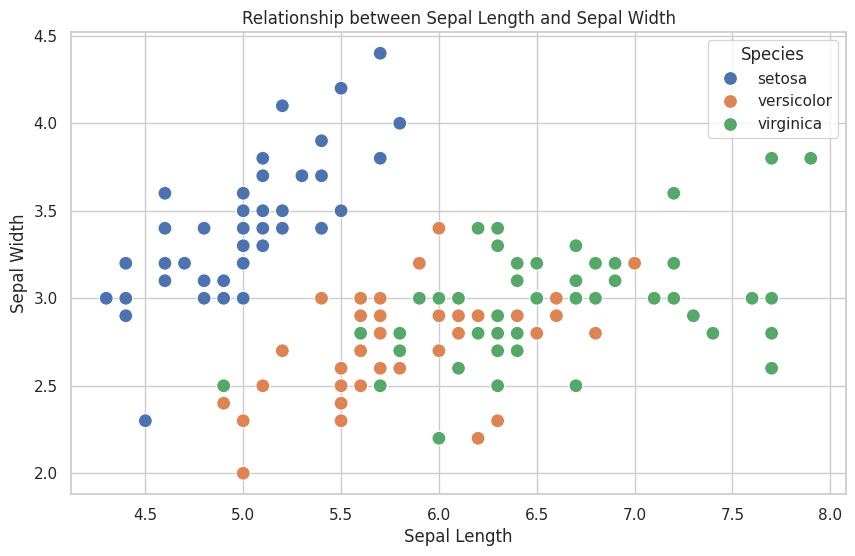

In [27]:
# Set plot style
sns.set_theme(style="whitegrid")

# Create Scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='sepal_length', y='sepal_width', hue='species', s=100)

plt.title('Relationship between Sepal Length and Sepal Width')
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.legend(title='Species')
plt.show()

### b. Visualization 2: Histogram
**Objective:** Examine the data distribution of a single variable.
We generate a histogram for **Petal Length**. This helps us visualize the frequency distribution and identify if the data is multimodal (having more than one peak).

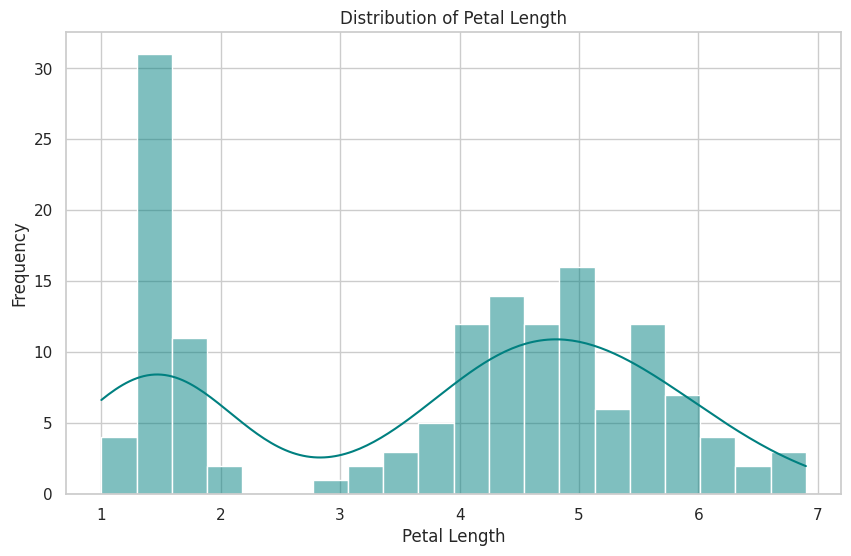

In [29]:
# Create Histogram
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='petal_length', bins=20, kde=True, color='teal')

plt.title('Distribution of Petal Length')
plt.xlabel('Petal Length')
plt.ylabel('Frequency')
plt.show()

### c. Visualization 3: Box Plot
**Objective:** Detect outliers and visualize the spread (variance) of values.
We use a box plot to compare the **Sepal Width** across the different species. This visualization highlights the median, the interquartile range (IQR), and any potential outliers.

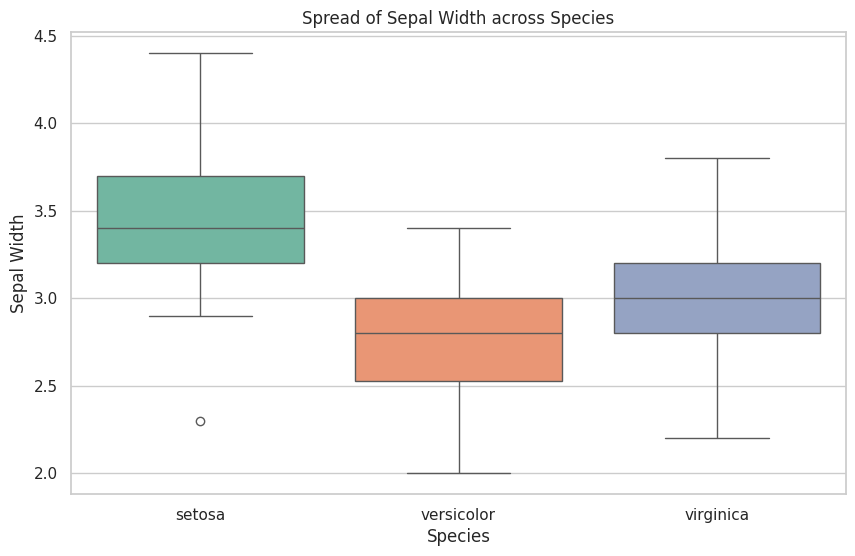

In [33]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df,
    x='species',
    y='sepal_width',
    hue='species',        # assign hue
    palette='Set2',
    legend=False          # avoid duplicate legend
)

plt.title('Spread of Sepal Width across Species')
plt.xlabel('Species')
plt.ylabel('Sepal Width')
plt.show()


## 6. Conclusion
In this task, we successfully loaded the Iris dataset using Pandas and performed Exploratory Data Analysis.

**Key Insights:**
1.  **Structure:** The dataset consists of 150 rows and 5 columns with no missing values, making it a clean dataset for analysis.
2.  **Clustering:** The scatter plot revealed that the *Setosa* species is linearly separable from *Versicolor* and *Virginica*, which show some overlap.
3.  **Distribution:** The histogram of petal length indicates a bimodal distribution, suggesting that one group of flowers has significantly smaller petals than the others.
4.  **Outliers:** The box plot highlighted that while *Versicolor* has a consistent sepal width, *Virginica* shows a wider spread, and there are a few outliers in the *Setosa* class.

This analysis confirms that the features—specifically petal dimensions—are strong differentiators for species classification.